In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split,KFold
from xgboost import XGBRegressor
import re

In [2]:
df=pd.read_csv("df_clean5.csv")
df=df.drop('Unnamed: 0', axis="columns")
df.head()

,longitude,latitude,housing_median_age,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,spatial_cluster,rooms_per_household,bedrooms_per_room,population_per_household,min_dist_to_hub
0,-122.23,37.88,0.784314,2.635927,452600.0,0,0,0,1,0,0,1.326138,-1.237081,-0.490566,-0.818014
1,-122.22,37.86,0.392157,2.622107,358500.0,0,0,0,1,0,0,0.741850,-1.066107,-1.100257,-0.817785
2,-122.24,37.85,1.000000,2.015878,352100.0,0,0,0,1,0,0,2.347488,-1.554206,-0.153100,-0.844111
3,-122.25,37.85,1.000000,1.078488,341300.0,0,0,0,1,0,0,0.412275,-0.533782,-0.500976,-0.854946
4,-122.25,37.85,1.000000,0.035066,342200.0,0,0,0,1,0,0,0.776091,-0.763387,-1.002281,-0.854946


In [3]:
X=df.drop('median_house_value',axis='columns')
y=df['median_house_value']

X.shape,y.shape

((19807, 14), (19807,))

## XGB Boost

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# shape of the X_train, X_test, y_train, y_test features
print("x train: ",X_train.shape)
print("x test: ",X_test.shape)
print("y train: ",y_train.shape)
print("y test: ",y_test.shape)

x train:  (13864, 14)
x test:  (5943, 14)
y train:  (13864,)
y test:  (5943,)


In [5]:
for char in ['[', ']', '<']:
    X_train.columns = X_train.columns.str.replace(char, '_', regex=False)
    X_test.columns = X_test.columns.str.replace(char, '_', regex=False)

In [6]:
print("X_train columns= ",X_train.columns)
print("X_test columns= ",X_test.columns)

X_train columns=  Index(['longitude', 'latitude', 'housing_median_age', 'median_income',
       'ocean_proximity__1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN', 'spatial_cluster', 'rooms_per_household',
       'bedrooms_per_room', 'population_per_household', 'min_dist_to_hub'],
      dtype='str')
X_test columns=  Index(['longitude', 'latitude', 'housing_median_age', 'median_income',
       'ocean_proximity__1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN', 'spatial_cluster', 'rooms_per_household',
       'bedrooms_per_room', 'population_per_household', 'min_dist_to_hub'],
      dtype='str')


In [11]:
X.columns = [re.sub(r"[\[\]<]", "", col) for col in X.columns]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

model_params = {
    "xgboost": {
        "model": XGBRegressor(
            random_state=42, objective="reg:squarederror", n_jobs=-1
        ),
        "params": {
           "n_estimators": [50,100, 200],
            "learning_rate": [0.01, 0.05, 0.1],
            "max_depth": [4, 6],
            "min_child_weight": [3, 5]
        }
    }
}

scores = []

for key, val in model_params.items():
    print(f"Training {key}...")
    clf = GridSearchCV(
        estimator=val["model"],
        param_grid=val["params"],
        cv=kf,
        scoring="r2",
        n_jobs=-1,
        return_train_score=False,
    )
    clf.fit(X, y)
    scores.append(
        {
            "model": key,
            "best_score": clf.best_score_,
            "best_params": clf.best_params_,
        }
    )

results_df = pd.DataFrame(scores)
results_df

Training xgboost...


,model,best_score,best_params
0,xgboost,0.845512,"{'learning_rate': 0.1, 'max_depth': 6, 'min_ch..."


In [12]:
results_df.best_params[0]

{'learning_rate': 0.1,
 'max_depth': 6,
 'min_child_weight': 5,
 'n_estimators': 200}

In [15]:
model_xgb = XGBRegressor(n_estimators=200, max_depth=6,learning_rate=0.1,min_child_weight=5,random_state=42, objective="reg:squarederror", n_jobs=-1)
model_xgb.fit(X_train, y_train)
test_score = model_xgb.score(X_test, y_test)
train_score = model_xgb.score(X_train, y_train)
train_score, test_score

(0.9312040061163521, 0.8369168187953095)

In [16]:
y_pred = model_xgb.predict(X_test)

mse_xgb = mean_squared_error(y_test, y_pred)
rmse_xgb = np.sqrt(mse_xgb)
print("XGB boost ==> MSE: ", mse_xgb, "RMSE: ", rmse_xgb)

XGB boost ==> MSE:  2192738987.009042 RMSE:  46826.6909679623


In [17]:
feature_importances = pd.Series(model_xgb.feature_importances_, index=X_train.columns)
print(feature_importances.sort_values(ascending=False))

ocean_proximity_INLAND        0.567455
median_income                 0.205065
population_per_household      0.051940
ocean_proximity_NEAR OCEAN    0.038355
min_dist_to_hub               0.027729
latitude                      0.023247
longitude                     0.023108
housing_median_age            0.020241
ocean_proximity_NEAR BAY      0.014075
rooms_per_household           0.010983
ocean_proximity__1H OCEAN     0.009968
bedrooms_per_room             0.007834
spatial_cluster               0.000000
ocean_proximity_ISLAND        0.000000
dtype: float32


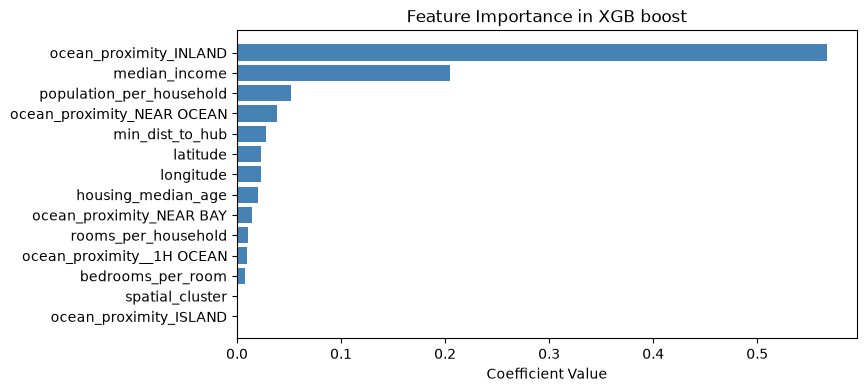

In [18]:
# Create a DataFrame for easier handling
coef_df = pd.DataFrame(feature_importances, index=X_train.columns, columns=['Coefficients'])

# Sort the coefficients for better visualization
coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

# Plotting
plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in XGB boost')
plt.show()

In [19]:
y_pred = model_xgb.predict(X_test)

residuals = y_pred - y_test
residuals_pct = (residuals / y_test) * 100

results_df_xgb = pd.DataFrame({
    'actual': y_test, 
    'predicted': y_pred, 
    'diff': residuals, 
    'diff_pct': residuals_pct
})
results_df_xgb.head()

,actual,predicted,diff,diff_pct
10863,170300.0,192315.156250,22015.156250,12.927279
17547,417800.0,428974.625000,11174.625000,2.674635
911,190400.0,193103.484375,2703.484375,1.419897
3015,109400.0,139938.953125,30538.953125,27.914948
11919,86500.0,80614.750000,-5885.250000,-6.803757


In [20]:
results_df_xgb.shape

(5943, 4)

In [21]:
results_df_xgb.describe()

,actual,predicted,diff,diff_pct
count,5943.000000,5943.000000,5943.000000,5943.000000
mean,206379.685008,205447.265625,-932.425184,4.635630
std,115964.597082,105771.429688,46821.346069,28.152822
min,14999.000000,30200.578125,-407072.234375,-81.414284
25%,118700.000000,124782.597656,-16378.636719,-7.996370
50%,179200.000000,185091.000000,3490.765625,2.214950
75%,263800.000000,260157.859375,20518.390625,14.022805
max,500001.000000,547573.625000,296507.437500,674.912422


In [22]:
results_df_xgb[(results_df_xgb['diff_pct']>100) | (results_df_xgb['diff_pct']<0)].shape

(2718, 4)

In [23]:
results_df_xgb[(results_df_xgb['diff_pct']>0) & (results_df_xgb['diff_pct']<50)].shape

(3112, 4)

In [24]:
results_df_xgb['diff_pct'].quantile(0.9)

np.float64(27.392047063126807)

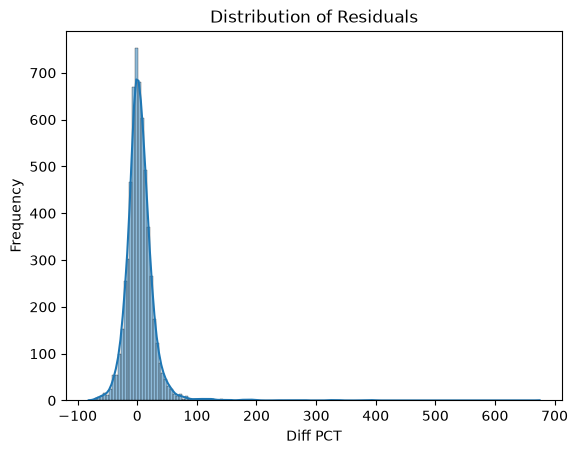

In [25]:
sns.histplot(results_df_xgb['diff_pct'], kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Diff PCT')
plt.ylabel('Frequency')
plt.show()

In [27]:
extreme_error_threshold_10 = 10.0 
extreme_results_df_xgb_10 = results_df_xgb[np.abs(results_df_xgb['diff_pct']) > extreme_error_threshold_10]
extreme_results_df_xgb_10.head()

,actual,predicted,diff,diff_pct
10863,170300.0,192315.156250,22015.156250,12.927279
3015,109400.0,139938.953125,30538.953125,27.914948
484,446200.0,385045.250000,-61154.750000,-13.705681
7228,117300.0,135872.203125,18572.203125,15.833080
12850,92000.0,137087.843750,45087.843750,49.008526


In [28]:
extreme_results_df_xgb_10.shape

(3194, 4)

In [29]:
extreme_errors_pct_xgb_10 = extreme_results_df_xgb_10.shape[0]*100/X_test.shape[0]
extreme_errors_pct_xgb_10

53.74390038700993

We have 53.74% extreme errors which means for 53.74% customers we will either overcharge or undercharge by 10% or more

In [32]:
extreme_error_threshold_25 = 25.0 
extreme_results_df_xgb_25 = results_df_xgb[np.abs(results_df_xgb['diff_pct']) > extreme_error_threshold_25]
extreme_results_df_xgb_25.head()

,actual,predicted,diff,diff_pct
3015,109400.0,139938.953125,30538.953125,27.914948
12850,92000.0,137087.843750,45087.843750,49.008526
15501,92600.0,136517.671875,43917.671875,47.427291
17130,137500.0,282707.593750,145207.593750,105.605523
7462,202400.0,151231.703125,-51168.296875,-25.280779


In [33]:
extreme_results_df_xgb_25.shape

(1050, 4)

In [34]:
extreme_errors_pct_xgb_25 = extreme_results_df_xgb_25.shape[0]*100/X_test.shape[0]
extreme_errors_pct_xgb_25

17.6678445229682

We have 17.66% extreme errors which means for 17.66% customers we will either overcharge or undercharge by 25% or more

In [35]:
extreme_errors_df_xgb_10= X_test.loc[extreme_results_df_xgb_10.index]
extreme_errors_df_xgb_10.head(2)

,longitude,latitude,housing_median_age,median_income,ocean_proximity__1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,spatial_cluster,rooms_per_household,bedrooms_per_room,population_per_household,min_dist_to_hub
10863,-117.91,33.79,0.411765,0.269545,1,0,0,0,0,0,-0.624704,0.472206,-0.147007,-0.572890
3015,-117.70,35.64,0.137255,1.205889,0,1,0,0,0,0,1.122640,-1.079967,-0.030029,0.906391


In [36]:
extreme_errors_df_xgb_25 = X_test.loc[extreme_results_df_xgb_25.index]
extreme_errors_df_xgb_25.head(2)

,longitude,latitude,housing_median_age,median_income,ocean_proximity__1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,spatial_cluster,rooms_per_household,bedrooms_per_room,population_per_household,min_dist_to_hub
3015,-117.70,35.64,0.137255,1.205889,0,1,0,0,0,0,1.12264,-1.079967,-0.030029,0.906391
12850,-117.41,34.10,0.078431,-0.730849,0,1,0,0,0,0,0.61803,0.325174,-0.273440,-0.088398


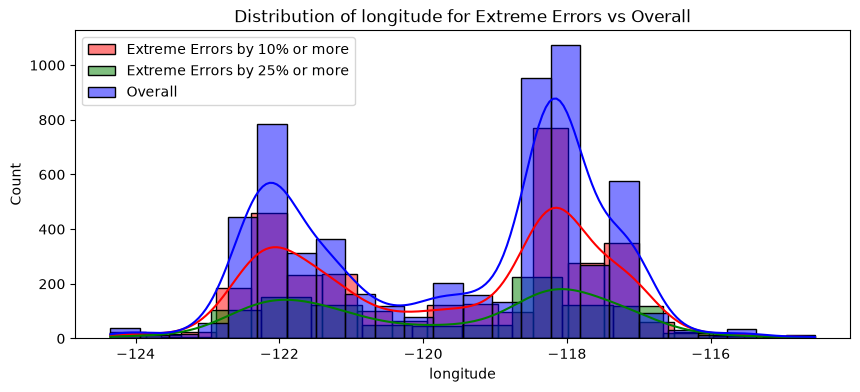

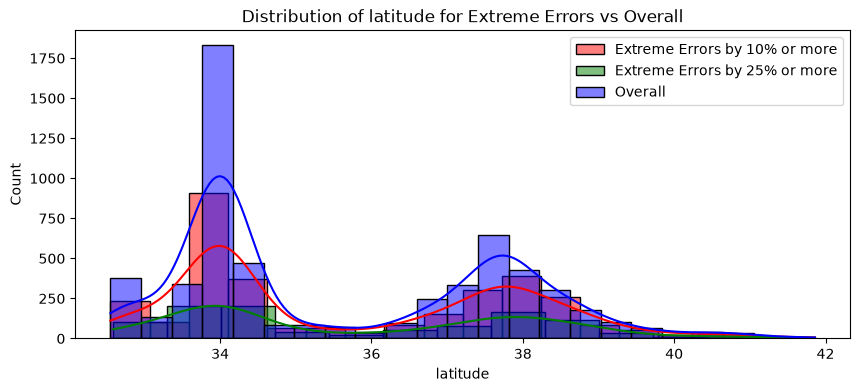

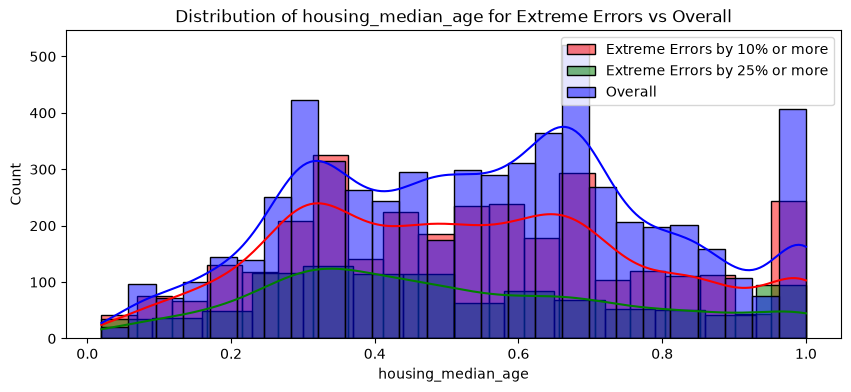

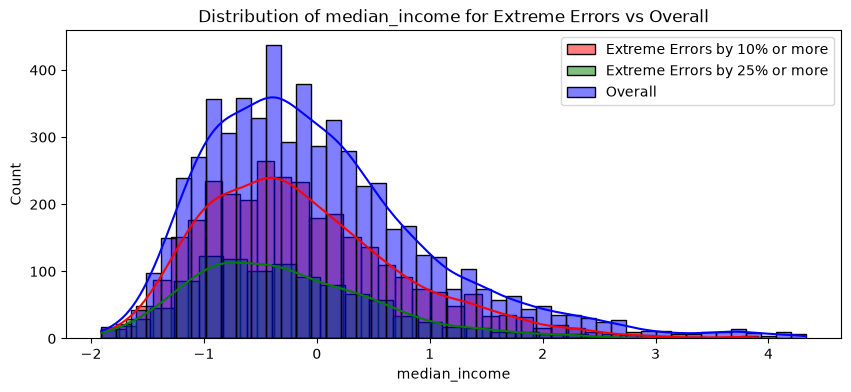

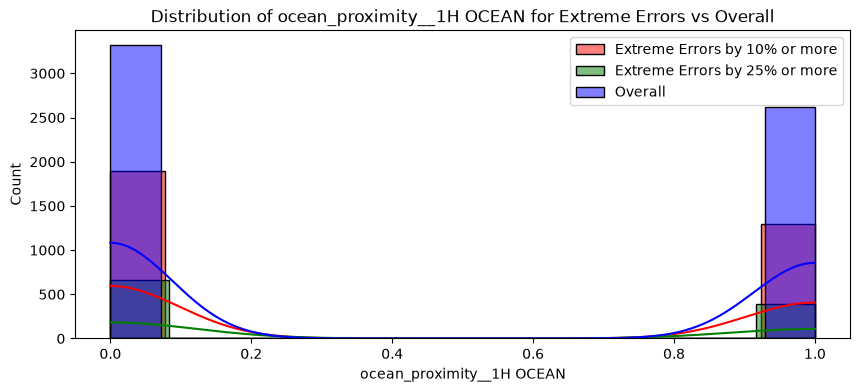

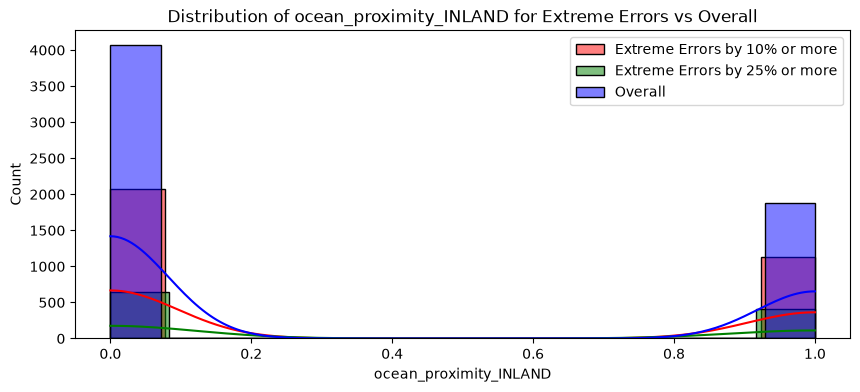

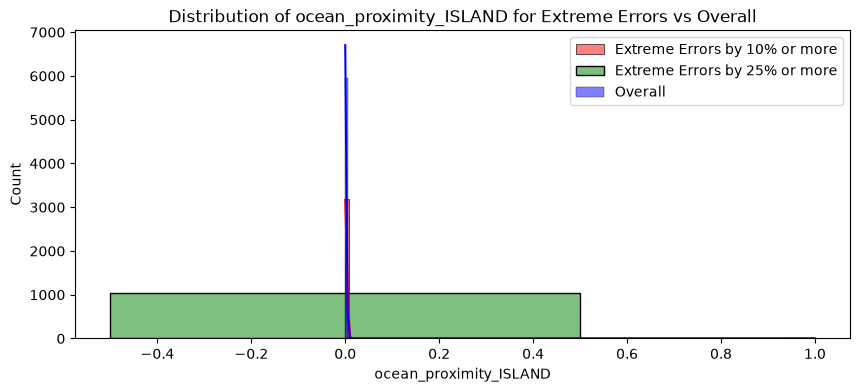

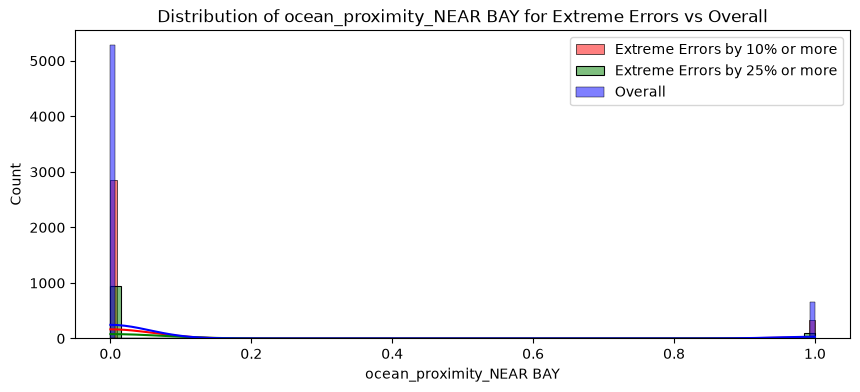

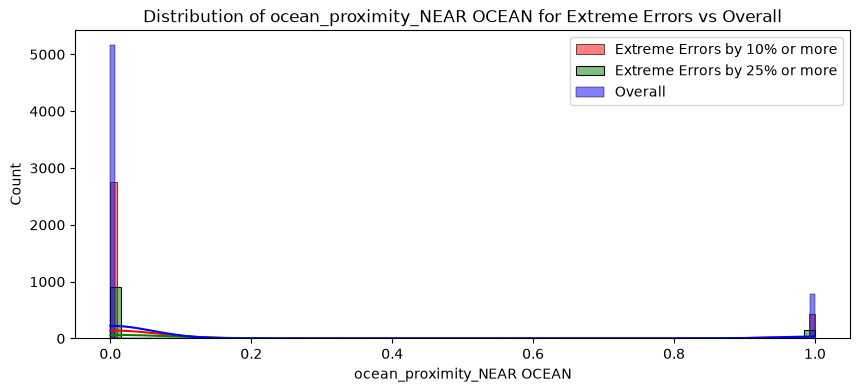

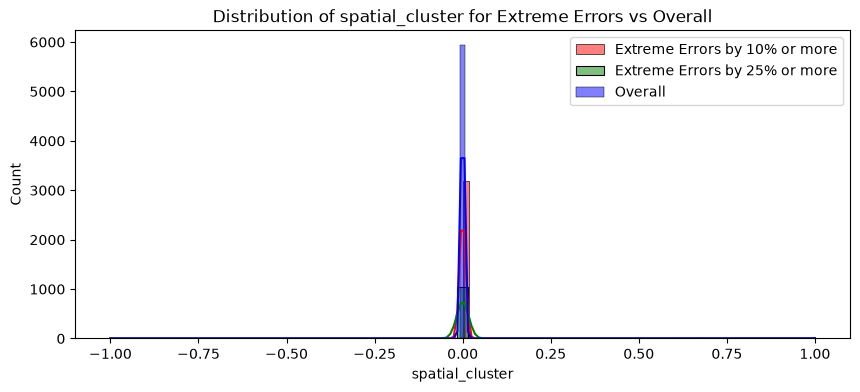

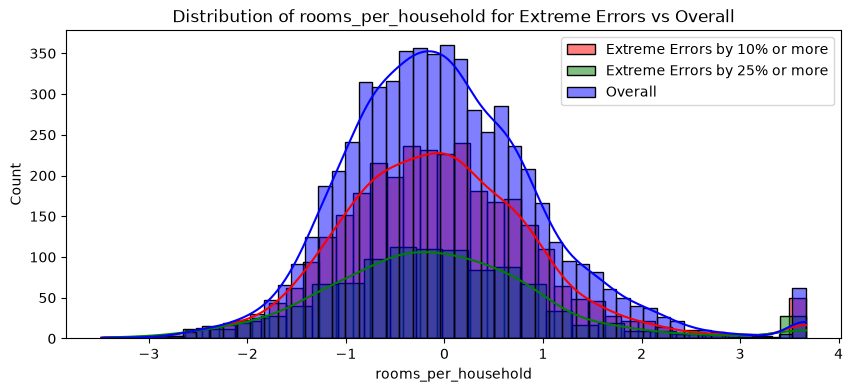

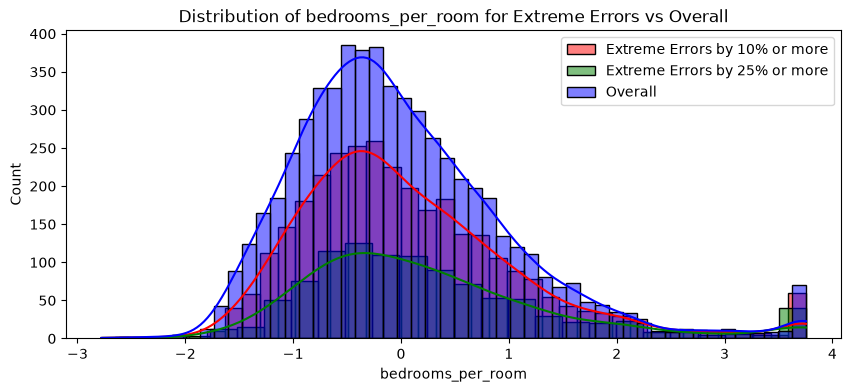

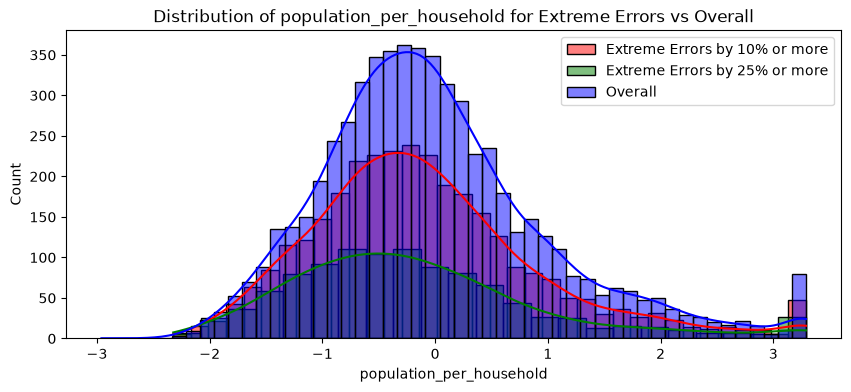

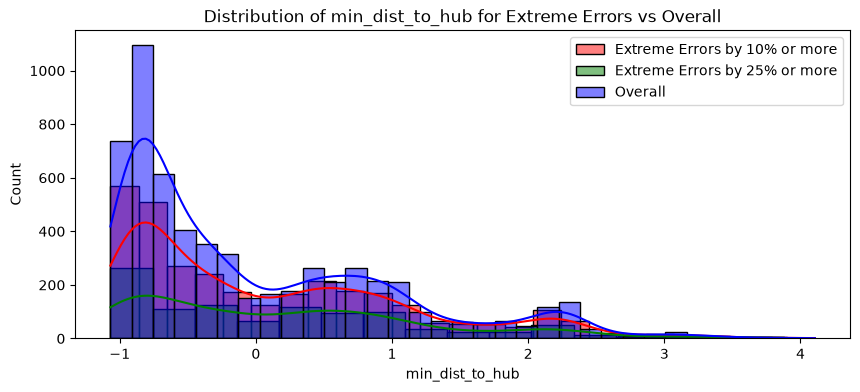

In [37]:
for feature in X_test.columns:
    plt.figure(figsize=(10,4))
    sns.histplot(extreme_errors_df_xgb_10[feature], color='red', label='Extreme Errors by 10% or more', kde=True)
    sns.histplot(extreme_errors_df_xgb_25[feature], color='green', label='Extreme Errors by 25% or more', kde=True)
    sns.histplot(X_test[feature], color='blue', label='Overall', alpha=0.5, kde=True)
    plt.legend()
    plt.title(f'Distribution of {feature} for Extreme Errors vs Overall')
    plt.show()

In [38]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"R² Score: {r2:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"MSE:      {mse:.4f}")
print(f"RMSE:     {rmse:.4f}")

R² Score: 0.8369
MAE:      29964.1999
MSE:      2192738987.0090
RMSE:     46826.6910


In [43]:
import joblib

top_features = feature_importances[feature_importances >=0.0].index.tolist()
print(f"Selected {len(top_features)} most valued features:\n{top_features}")

joblib.dump(model_xgb, 'xgboost_top_features_model.joblib')
joblib.dump(top_features, 'xgboost_top_feature_names.joblib')

print("\nModel and feature names successfully saved to joblib files!")

Selected 14 most valued features:
['longitude', 'latitude', 'housing_median_age', 'median_income', 'ocean_proximity__1H OCEAN', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN', 'spatial_cluster', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'min_dist_to_hub']

Model and feature names successfully saved to joblib files!
